Task Description: Fe Deficiency detection based on the different hyperspectral spectra (i.e., measuring leaf reflectance at different wavelengths in the range of 400 to 1000 nm).
#### <font color=red> Delete 18 spectra from the beginning and 17 from the end of all Train and Test sets --> 169 (from X449.35 up to X951.17) are left in the case of not reducing the size of dataset more </font>
#### Train size = Original dataset (144, 169)
#### Test size = Merge Anna 1, Anna 2, and Marco1 (86, 169) 
#### <font color=red> The SHAP plots are for class [1] which is "Fe deficiency" here </font>

#### Methods
- Logistic Regression (Linear)
- Random Forest

In [1]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer,  precision_score,  recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
# Initialize JavaScript for SHAP visualizations
shap.initjs()


['X702.58', 'X714.55', 'X705.57']
Class Distribution:
Thesis
+N+Fe    72
+N-Fe    72
Name: count, dtype: int64


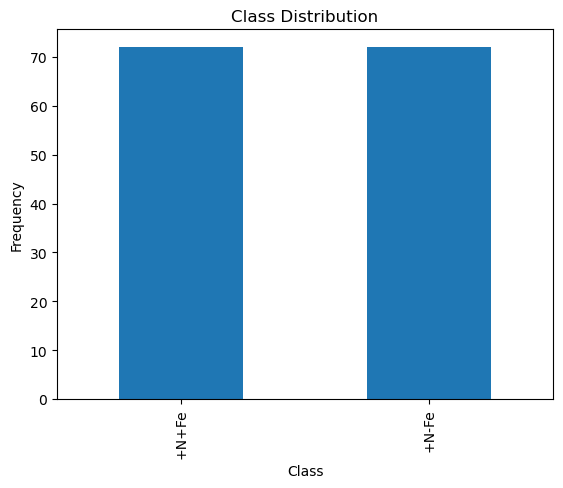

Columns with missing values: []

Number of features with 0.0 importance: 0


(144, 3)

In [17]:
# Step 1: Load the dataset
data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt', delimiter='\t')
# Step 2: Preprocess the data
# Drop the 'leaf' column
data = data.drop(columns=['Leaf'])
# Separate the dataset into features and labels
# 😎😎😎😎😎😎 new line, 1) include all Wavelengths
# X = data.iloc[:, 3:]  # Features
# 😎😎😎😎😎😎 new line, 2) remove nosiy Wavelengths/Trimmed
# X = data.iloc[:, 21:190]

#### SHAP FEATURES EXTRACTED WHEN ALL WAVELENGTHS WERE CONSIDERED ####
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Merged Dataset, All Features, Logistic Regression
# desired_columns = ['X714.55', 'X717.54', 'X711.56', 'X985.05', 'X997.40', 'X720.54', 'X994.31', 'X708.57', 'X723.53']
# For Merged Dataset, Some Features, Logistic Regression
# desired_columns = ['X714.55', 'X711.56', 'X708.57', 'X720.54', 'X705.57', 'X723.53', 'X702.58', 'X750.54', 'X726.53']
# For Merged Dataset, All Features, Random Forest
# desired_columns = ['X705.57', 'X702.58', 'X708.57', 'X711.56', 'X714.55', 'X569.12', 'X542.68', 'X699.60', 'X560.30']
# For Merged Dataset, Some Features, Random Forest
# desired_columns = ['X714.55', 'X702.58', 'X711.56', 'X708.57', 'X705.57', 'X566.18', 'X699.60', 'X589.75', 'X580.90']

#### SHAP FEATURES EXTRACTED WHEN TRIMMED WAVELENGTHS WERE CONSIDERED ####
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Merged Dataset, All Features, LogisticRegression
# desired_columns = ['X714.55', 'X717.54', 'X711.56', 'X720.54', 'X708.57', 'X723.53', 'X726.53', 'X729.53', 'X819.95']
# For Merged Dataset, Some Features, Logistic Regression
# desired_columns = ['X714.55', 'X753.55', 'X717.54', 'X756.56', 'X711.56', 'X708.57', 'X705.57', 'X720.54', 'X807.84']
# For Merged Dataset, All Features, Random Forest
# desired_columns = ['X702.58', 'X714.55', 'X705.57', 'X708.57', 'X711.56', 'X717.54', 'X563.24', 'X542.68', 'X720.54']
# For Merged Dataset, Some Features, Random Forest
#desired_columns = ['X711.56', 'X717.54', 'X708.57', 'X539.75', 'X545.62', 'X702.58', 'X648.95', 'X554.43','X563.24']


#### Ablation Test ###
# For Merged Dataset, All Features, LogisticRegression&Random, Use Top 3 ---> Index1
# desired_columns = ['X714.55', 'X717.54', 'X711.56'] 
# For Merged Dataset, All Features, RandomForest, Use Top 3 ---> Index2
desired_columns = ['X702.58', 'X714.55', 'X705.57'] 
# For Merged Dataset, All Features, Logistic & RandomForest, Use Common top 4 --->Index3
# desired_columns = ['X708.57', 'X711.56', 'X714.55', 'X717.54'] 

### Test single features in Index 1 above ###
# For Merged Dataset, All Features, 
# desired_columns = ['X702.58'] 
# desired_columns = ['X714.55'] 
# desired_columns = ['X705.57'] 
X = data[desired_columns]

y = data['Thesis']
feature_names = X.columns.tolist()
print(feature_names)
# Check the distribution/imbalance of the target variable
class_distribution = data['Thesis'].value_counts()
# Print the class distribution
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

# Encode the 'Thesis' column
le = LabelEncoder()
y = le.fit_transform(y)

# Check for missing values --> none
print(f"Columns with missing values: {data.columns[data.isnull().any()].tolist()}")

# Feature selection ------------------>??
rf = RandomForestClassifier(n_estimators=15, random_state=42)
rf.fit(X, y)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
# Count the number of features with 0.0 importance and print their names
zero_importance_features = feature_importances[feature_importances == 0.0].index.tolist()
print(f"\nNumber of features with 0.0 importance: {len(zero_importance_features)}")
# print("Features with 0.0 importance:", zero_importance_features)
# print("\nFeature Importances:")
# print(feature_importances.sort_values(ascending=False))
# Remove zero importance features from X
# X_reduced = X.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced.columns.tolist()
# print("\nX_reduced.shape is ", X_reduced.shape)
# print("\nX_reduced names.shape is ", len(feature_names_reduced))
# print(feature_names_reduced)
#Scale the feature/columns values
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_reduced)
X_scaled = scaler.fit_transform(X)
X_scaled.shape

### Test Set Preparation
#### Merge Anna 1, Anna 2, and Marco

In [43]:
# # Read the first file normally (to include its header if needed)
# data1 = pd.read_csv('Exp_I_Anna_Fe_Tomato.txt', sep='\t', header=None)  # Shape (18, 207)

# # Read the second and third files while skipping their headers
# data2 = pd.read_csv('Exp_II_Anna_Fe_Tomato.txt', sep='\t', header=None, skiprows=1)  # Skip the header row
# data3 = pd.read_csv('Exp_Marco_tesista_Fe_Lupino.txt', sep='\t', header=None, skiprows=1)  # Skip the header row

# # Concatenate the data vertically
# final_data = pd.concat([data1, data2, data3])

# # Verify the shape of the final data
# print(data1.shape)
# print(data2.shape)
# print(data3.shape)
# print("Final shape:", final_data.shape)  # Should print (86, 207)

# # Save the combined data to a new tab-delimited .txt file
# final_data.to_csv('Merged_Anna1_Anna2_Marco_as_test.txt', sep='\t', index=False, header=False)


    X702.58   X714.55   X705.57
0  0.189029  0.371862  0.233366
1  0.201145  0.387255  0.247125
2  0.192173  0.371062  0.236553
3  0.186251  0.366757  0.229916
4  0.188142  0.362862  0.230441
Class Distribution:
Thesis
+N-Fe    56
+N+Fe    30
Name: count, dtype: int64


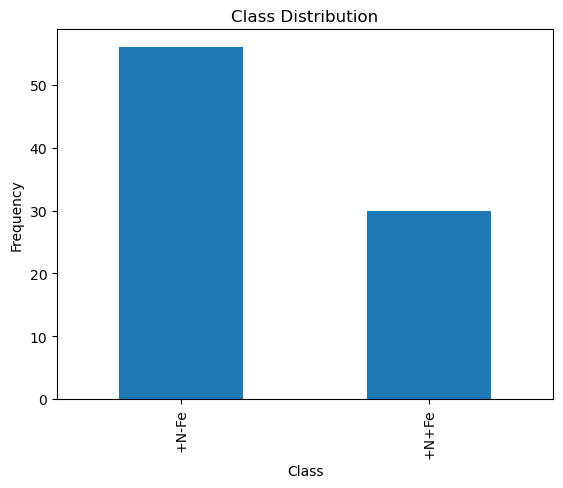

Columns with missing values: []
(86, 3)


In [18]:
# Step 1: Load the dataset
test_df = pd.read_csv('Merged_Anna1_Anna2_Marco_as_test.txt', delimiter='\t')
# Step 2: Preprocess the data
# Rename the column "Fe deficiency" to "Thesis"
test_df.rename(columns={'Fe_deficiency ': 'Thesis'}, inplace=True)

# # Separate the dataset into features and labels
# 😎😎😎😎😎😎 new line, 1) include all Wavelengths
# X_te = test_df.iloc[:, 3:]
# 😎😎😎😎😎😎 new line, 2) remove nosiy Wavelengths/Trimmed
# X_te = test_df.iloc[:, 21:190]

#### SHAP FEATURES EXTRACTED WHEN ALL WAVELENGTHS WERE CONSIDERED ####
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Merged Dataset, All Features, Logistic Regression
# desired_columns1 = ['714.55', '717.54', '711.56', '985.05', '997.4', '720.54', '994.31', '708.57', '723.53']
# For Merged Dataset, Some Features, Logistic Regression
# desired_columns1 = ['714.55', '711.56', '708.57', '720.54', '705.57', '723.53', '702.58', '750.54', '726.53']
# For Merged Dataset, All Features, Random Forest
# desired_columns1 = ['705.57', '702.58', '708.57', '711.56', '714.55', '569.12', '542.68', '699.6', '560.3']
# For Merged Dataset, Some Features, Random Forest
# desired_columns1 = ['714.55', '702.58', '711.56', '708.57', '705.57', '566.18', '699.6', '589.75', '580.9']

#### SHAP FEATURES EXTRACTED WHEN TRIMMED WAVELENGTHS WERE CONSIDERED ####
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Merged Dataset, All Features, LogisticRegression
# desired_columns1 = ['714.55', '717.54', '711.56', '720.54', '708.57', '723.53', '726.53', '729.53', '819.95']
# For Merged Dataset, Some Features, Logistic Regression
# desired_columns1 = ['714.55', '753.55', '717.54', '756.56', '711.56', '708.57', '705.57', '720.54', '807.84']
#For Merged Dataset, All Features, Random Forest
# desired_columns1 = ['702.58', '714.55', '705.57', '708.57', '711.56', '717.54', '563.24', '542.68', '720.54']
# For Merged Dataset, Some Features, Random Forest
# desired_columns = ['711.56', '717.54', '708.57', '539.75', '545.62', '702.58', '648.95', '554.43','563.24']

#### Ablation Test ###
# For Merged Dataset, All Features, LogisticRegression & Random, Use Top 3
# desired_columns1 = ['714.55', '717.54', '711.56'] 
# For Merged Dataset, All Features, RandomForest, Use Top 3
desired_columns1 = ['702.58', '714.55', '705.57'] 
# For Merged Dataset, All Features, Logistic&RandomForest, Use Common top 4
# desired_columns1 = ['708.57', '711.56', '714.55', '717.54'] 

### Test single features in Index 1 above ###
# For Merged Dataset, All Features, 
# desired_columns1 = ['702.58'] 
# desired_columns1 = ['714.55'] 
# desired_columns1 = ['705.57'] 
X_te= test_df[desired_columns1]

# Ensure that X_te has the correct number of columns as X
X_te.columns = X.columns  # Update the column names to match those in X (original dataset)
# Verify the change
print(X_te.head())
y_te = test_df['Thesis']

# Check the distribution/imbalance of the target variable
class_distribution = test_df['Thesis'].value_counts()
# Print the class distribution
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

# # Encode the 'Thesis' column
le_te = LabelEncoder()
y_te = le_te.fit_transform(y_te)

# Check for missing values --> none
print(f"Columns with missing values: {test_df.columns[test_df.isnull().any()].tolist()}")

# Remove zero importance features from X_te
# X_reduced_te = X_te.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced_te.columns.tolist()
# print("\nX_reduced_te.shape is ", X_reduced_te.shape)
# print("\nX_reduced_te names.shape is ", len(feature_names_reduced))
# Scale the feature/columns values
scaler = StandardScaler()
# X_scaled_te = scaler.fit_transform(X_reduced_te)
X_scaled_te = scaler.fit_transform(X_te)
print(X_scaled_te.shape)



#### Very important: Check if encoded labels are consistant in original and each of the tested datasets

In [19]:
print("Label Encoding Mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

print("Label Encoding Mapping:")
for i, label in enumerate(le_te.classes_):
    print(f"{label}: {i}")

# # Display the original and encoded values in the Thesis column
# print("Original and Encoded Thesis Labels:")
# test_df_miki['Original_Thesis'] = pd.read_csv('Exp_4_Specie_Michele_Fe_and_N.txt', delimiter='\t')['Thesis']  # Reload original data for comparison
# print(test_df_miki[['Original_Thesis', 'Thesis']].drop_duplicates())



Label Encoding Mapping:
+N+Fe: 0
+N-Fe: 1
Label Encoding Mapping:
+N+Fe: 0
+N-Fe: 1


#### <font color=red> New </font>
#### - Train Set: all of the data data in the "original" dataset
#### - Test Set: all of the data data in "Anna1, Anna2, Marco" dataset


In [20]:
# 😎😎😎😎😎😎 new line
X_train, y_train = X_scaled, y
X_test, y_test = X_scaled_te, y_te

# Confirm the shape of the train and test sets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (144, 3), y_train shape: (144,)
X_test shape: (86, 3), y_test shape: (86,)


#### Hyperparameter Tuning Using GridSearchCV , Model Training, and Evaluation
- Linear Logistic Regression </font>
- Randomforest

- <font color=red> Crossfold Validation in GridSearch (Hyperparameter tuning)</font>

#### <font color=green> Standard Logistic Regression </font>

Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Cross-Validation Scores from GridSearchCV:
     mean_test_score  std_test_score  \
0          0.875862        0.142343   
1          0.875862        0.142343   
2          0.875862        0.142343   
3          0.882759        0.131939   
4          0.875862        0.142343   
5          0.882759        0.131939   
6          0.951724        0.067572   
7          0.944828        0.063956   
8          0.951724        0.067572   
9          0.979310        0.041379   
10         0.979310        0.041379   
11         0.979310        0.041379   
12         0.972414        0.040213   
13         0.972414        0.040213   
14         0.972414        0.040213   

                                               params  
0     {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}  
1   {'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...  
2       {'C': 0.01, 'penalty': 'l2', 'solver': 'sag'}  
3      {'C': 0.1, '

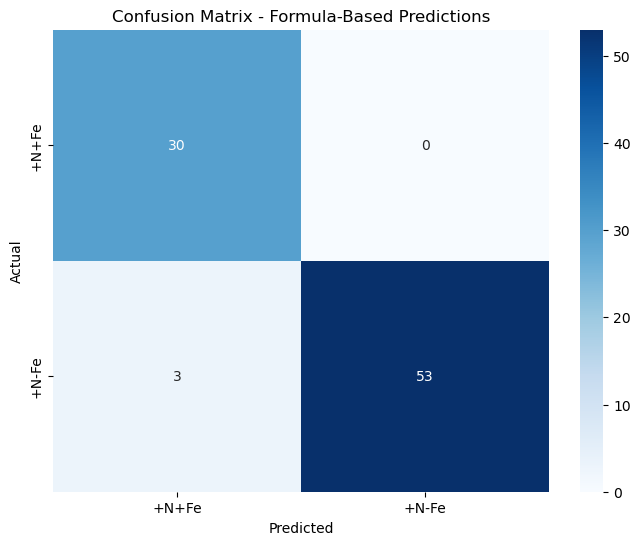


Standard Logistic Regression - Test Set Accuracy: 0.9651162790697675
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        30
           1       1.00      0.95      0.97        56

    accuracy                           0.97        86
   macro avg       0.95      0.97      0.96        86
weighted avg       0.97      0.97      0.97        86

Unique values in y_te: [0 1]
Unique values in y_pred: [0 1]


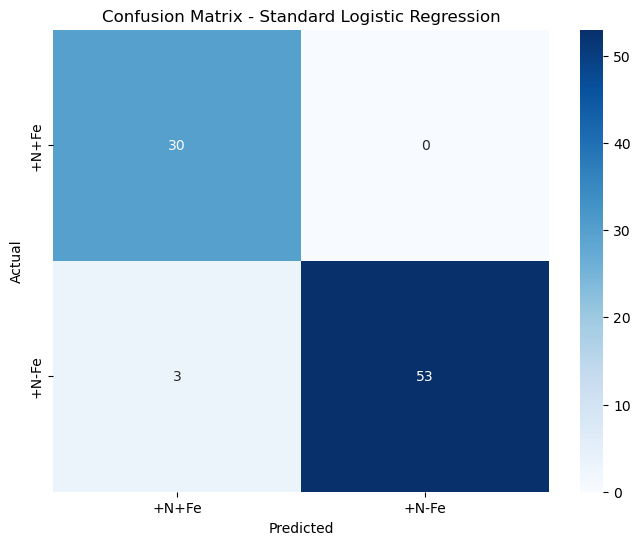

In [21]:
### Hyperparameter Tuning and Cross-Validation for Standard Logistic Regression ###
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 30],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear', 'sag']
}
random_state= 42
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000, tol=1e-3,random_state=random_state), param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)
best_params_lr = grid_search_lr.best_params_
print("Best parameters for Logistic Regression:", best_params_lr)

# Print Cross-Validation Scores from GridSearchCV
cv_results = pd.DataFrame(grid_search_lr.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best logistic regression model
model = LogisticRegression(**best_params_lr, max_iter=5000, tol=1e-3, random_state=random_state)

# # Perform cross-validation
# cv_scores_lr = cross_val_score(model, X_train, y_train, cv=5)
# print("\nStandard Logistic Regression - Cross-Validation Scores:", cv_scores_lr)
# print("Mean Cross-Validation Score:", cv_scores_lr.mean())

# Train the model on the entire training set
model.fit(X_train, y_train)

# Extract coefficients and intercept
coefficients = model.coef_[0]  # For binary classification; adjust for multiclass
intercept = model.intercept_[0]  # For binary classification; adjust for multiclass
# Print coefficients and intercept with feature names
print("Intercept:", intercept)
print("Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
# Save the coefficients and intercept to a .txt file without rounding
output_file = "feature_coefficients_exact.txt"
with open(output_file, "w") as f:
    f.write(f"Intercept: {intercept}\n")
    f.write("Coefficients:\n")
    for feature, coef in zip(feature_names, coefficients):
        f.write(f"{feature}: {coef}\n")
print(f"Exact coefficients and intercept saved to {output_file}")
# Make predictions on the test set
y_pred = model.predict(X_scaled_te)
# Calculate predictions using the logistic regression formula
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Compute the linear combination (z)
z = intercept + np.dot(X_scaled_te, coefficients)  # Use the test set features
# Apply sigmoid to get probabilities
probabilities = sigmoid(z)
# Convert probabilities to binary predictions with a threshold of 0.5
predictions_formula = (probabilities >= 0.5).astype(int)
# Validate against the genuine y_te
print("\nValidation of Logistic Regression Formula:")
print("Accuracy:", accuracy_score(y_te, predictions_formula))
print("Classification Report:\n", classification_report(y_te, predictions_formula))
# Plot confusion matrix as a heatmap for formula-based predictions
conf_matrix_formula = confusion_matrix(y_te, predictions_formula)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_formula, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Formula-Based Predictions")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# # Model Evaluation for Standard Logistic Regression
print("\nStandard Logistic Regression - Test Set Accuracy:", accuracy_score(y_te, y_pred))
print("Test Set Classification Report:")
print(classification_report(y_te, y_pred))
# make sure the labels match
print("Unique values in y_te:", np.unique(y_te))
print("Unique values in y_pred:", np.unique(y_pred))
# Confusion Matrix
conf_matrix = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Standard Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# # NEW: SHAP ANALYSIS
# # Use LinearExplainer for logistic regression
# explainer_llr = shap.LinearExplainer(model, X_train)
# # Calculate SHAP values
# shap_values_llr = explainer_llr.shap_values(X_train)
# print("Linear Logistic Regression shap_values shape is", np.shape(shap_values_llr))
# # Ensure base_values is an array
# base_values_llr = np.full(shap_values_llr.shape[0], explainer_llr.expected_value)
# # Create an Explanation object
# shap_values_llr_explanation = shap.Explanation(
#     shap_values_llr,
#     base_values=base_values_llr,
#     data=X_train,
#     # feature_names = feature_names_reduced
#     feature_names=feature_names
# )
# # Generate SHAP plots
# # Summary Plot
# shap.summary_plot(shap_values_llr, X_train, feature_names=feature_names)
# # shap.summary_plot(shap_values_llr, X_train, feature_names=feature_names_reduced)
# # Bar Plot
# shap.plots.bar(shap_values_llr_explanation, max_display=10)
# # Beeswarm Plot
# shap.plots.beeswarm(shap_values_llr_explanation)
# print(shap_values_llr_explanation.shape)
# # Waterfall Plot for the first instance
# shap.plots.waterfall(shap_values_llr_explanation[1])

# print("Model classes:", model.classes_)

#### <font color=green> Random Forest </font>

Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Cross-Validation Scores from GridSearchCV:
      mean_test_score  std_test_score  \
0           0.951478        0.035072   
1           0.951478        0.035072   
2           0.951478        0.035072   
3           0.951478        0.035072   
4           0.951478        0.035072   
..               ...             ...   
283         0.965271        0.037777   
284         0.965271        0.037777   
285         0.965271        0.037777   
286         0.965271        0.037777   
287         0.965271        0.037777   

                                                params  
0    {'max_depth': None, 'max_features': 'sqrt', 'm...  
1    {'max_depth': None, 'max_features': 'sqrt', 'm...  
2    {'max_depth': None, 'max_features': 'sqrt', 'm...  
3    {'max_depth': None, 'max_features': 'sqrt', 'm...  
4    {'max_depth': None, 'max_features': '

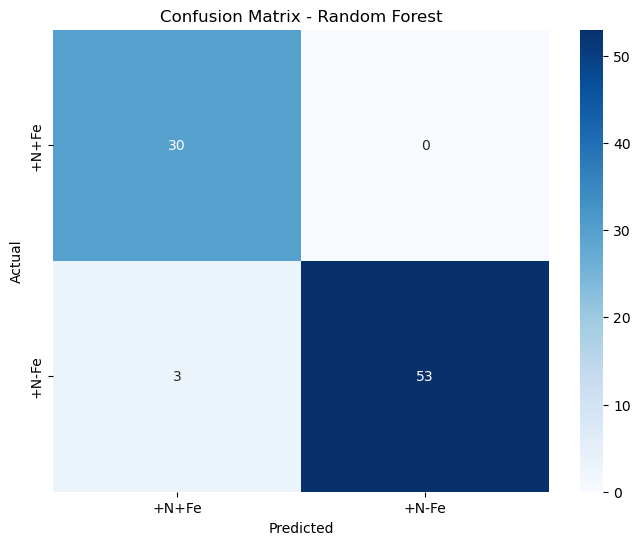

Random Forest shap_values shape is (144, 1, 2)
Selected SHAP values shape: (144, 1)


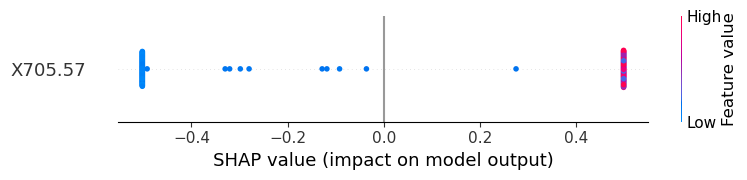

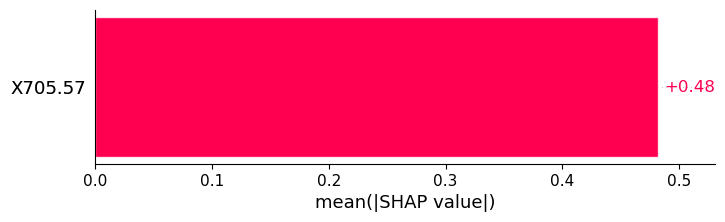

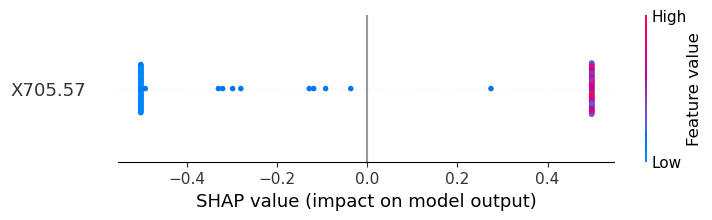

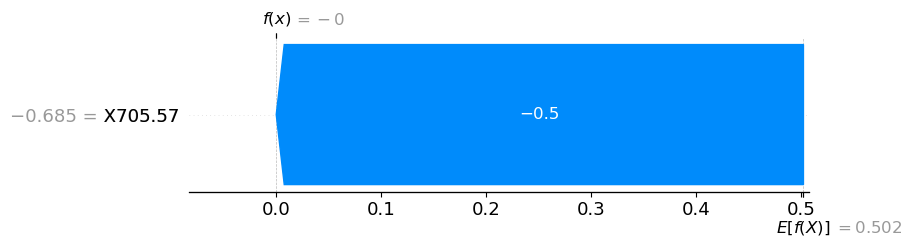

Model classes: [0 1]


In [116]:
### Random Forest Classifier ###
# Hyperparameter Tuning and Cross-Validation for Random Forest
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# Set a random_state for reproducibility
random_state = 42
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_params_rf = grid_search_rf.best_params_
print("Best parameters for Random Forest:", best_params_rf)

# Print Cross-Validation Scores from GridSearchCV
cv_results_rf = pd.DataFrame(grid_search_rf.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_rf[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best Random Forest model
rf_model = RandomForestClassifier(**best_params_rf,random_state=random_state)

# Train the model on the entire training set
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_scaled_te)

# Model Evaluation for Random Forest
print("\nRandom Forest - Test Set Accuracy:", accuracy_score(y_te, y_pred_rf))
print("Test Set Classification Report:")
print(classification_report(y_te, y_pred_rf))

# make sure the labels match
print("Unique values in y_te:", np.unique(y_te))
print("Unique values in y_pred:", np.unique(y_pred))


# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_te, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SHAP Analysis
# Use TreeExplainer for Random Forest
explainer_rf = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values_rf = explainer_rf.shap_values(X_train)
print("Random Forest shap_values shape is", np.shape(shap_values_rf))

# Select the SHAP values for the positive class (class 1)
shap_values_rf_selected = shap_values_rf[:, :, 1]
# Print the shape of the resulting array
print("Selected SHAP values shape:", shap_values_rf_selected.shape)

# Create an Explanation object
shap_values_rf_explanation = shap.Explanation(
    shap_values_rf_selected,
    base_values=explainer_rf.expected_value[1],  # Use the expected value of the positive class
    data=X_train,
    feature_names=feature_names
    # feature_names=feature_names_reduced
)

# Generate SHAP plots
# Summary Plot
shap.summary_plot(shap_values_rf_explanation, X_train, feature_names=feature_names)
# shap.summary_plot(shap_values_rf_explanation, X_train, feature_names=feature_names_reduced)
# Bar Plot
shap.plots.bar(shap_values_rf_explanation)

# Beeswarm Plot
shap.plots.beeswarm(shap_values_rf_explanation)

# Waterfall Plot for the first instance
shap.plots.waterfall(shap_values_rf_explanation[0])

print("Model classes:", rf_model.classes_)